# 11 · PET images: from raw scanner files to a checked pipeline and an image model

**Starting point.** 599 raw PET scans on disk (318 amyloid, 232 tau, 49 FDG) from about 20 scanner models. Each is a *dynamic* DICOM series of hundreds to thousands of files, in the scanner's own coordinate system, in raw activity units.

**What this notebook shows.**

1. How the raw files become one 3D image per scan in a common space.
2. **Proof that the pipeline is right:** amyloid SUVR measured from our images agrees with the values NACC's PET core computed for the same scans with a different pipeline.
3. An image model with a target the data can support: amyloid positive versus negative, with Grad-CAM.

**What it does not do.** It does not predict cognitive decline from images. Only 5 of the 446 people with an image went on to dementia (notebook 04). No image model can learn from 5 examples, and pretending otherwise would be the weakest point of the whole project.

Individual brain images are participant data and are never shown. Every picture here is an **average over a group**.

In [1]:
import sys, json
sys.path.insert(0, "../scripts")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import SimpleITK as sitk
import nacc_utils as nu

nu.set_style()
P = nu.REPO / "data" / "processed"
conv = pd.read_csv(P / "pet_static" / "conversion_log.csv")
reg = pd.read_csv(P / "pet_mni" / "registration_log.csv")
suv = json.loads((nu.REPORTS / "phase5_pet_image_results.json").read_text())
print(f"Converted: {int(conv.ok.sum())} of {len(conv)} scans. Registered (pass 2): {int(reg[reg['pass'] == 2].ok.sum())} of {int((reg['pass'] == 2).sum())}.")

Converted: 599 of 599 scans. Registered (pass 2): 599 of 599.


## 1. The pipeline

| Step | Script | What it does | Why |
|---|---|---|---|
| 1. Read | `pet_convert.py` | Reads every DICOM slice and applies its rescale factor to get activity (Bq/ml) | Stored pixel values are not activity until rescaled |
| 2. Frames | `pet_convert.py` | Groups slices into time frames and orders each frame bottom to top | A dynamic series is the same volume repeated over time |
| 3. Time window | `pet_convert.py` | Keeps frames inside the tracer's standard window after injection (for example 50-70 min for PiB, 90-110 min for florbetaben) | SUVR is only comparable when measured in the same window |
| 4. Average | `pet_convert.py` | Duration-weighted mean of the kept frames, saved as one 3D image | Reduces noise; gives one image per scan |
| 5. Align, pass 1 | `pet_register.py` | Rotates and shifts each image onto the MNI152 template, using mutual information | Puts all heads in the same position and orientation |
| 6. Template | `pet_register.py` | Averages the pass-1 images per tracer class | Gives a PET-shaped target, which is easier to match than an MRI |
| 7. Align, pass 2 | `pet_register.py` | Full affine alignment of each image to that PET template | Corrects size and shape differences between heads |
| 8. SUVR | `pet_suvr.py` | Mean uptake in the cortical target region divided by mean uptake in the whole cerebellum, using the Centiloid project's standard masks | The standard way amyloid PET is quantified |

The raw files are only ever read. All outputs go to `data/processed`, which is not in git.

**Two design decisions worth being able to explain.**

* **No MRI.** Standard pipelines register each PET to the person's own MRI. There is no MRI on disk, so this is a PET-only pipeline. That is a recognised approach, somewhat less precise.
* **Why pass 1 only rotates and shifts.** A first attempt let pass 1 also stretch the image. PET shows the scalp and skull while the MRI template is skull-stripped, and the optimiser stretched heads by up to 70% to compensate. Restricting pass 1 to rotation and shift, and doing the stretching PET-to-PET in pass 2, fixed it. An automatic fit of the averaged PET image to the MRI template was also tried and rejected for the same reason.

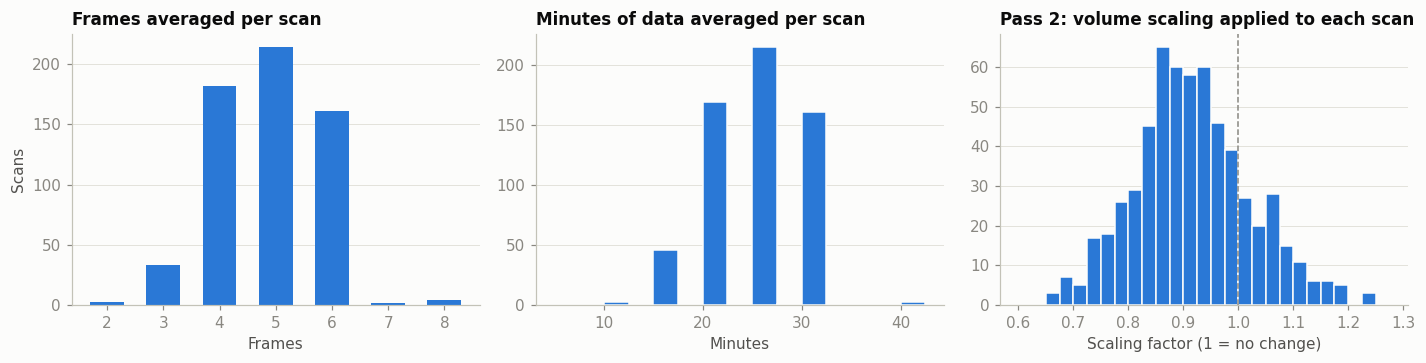

Scans whose header timing puts the first averaged frame within 0-200 minutes of injection: 596 of 599. The rest have unusable injection times in the header; all their frames were averaged.
Pass-2 volume scaling: median 0.91, range 0.66 to 1.24


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
fu = conv.frames_used.value_counts().sort_index()
axes[0].bar(fu.index.astype(int).astype(str), fu.values, color=nu.BLUE, width=0.6); axes[0].set_title("Frames averaged per scan"); axes[0].set_xlabel("Frames"); axes[0].set_ylabel("Scans")
mins = conv.seconds_averaged / 60
axes[1].hist(mins, bins=np.arange(5, 45, 2.5), color=nu.BLUE, edgecolor="#fcfcfb"); axes[1].set_title("Minutes of data averaged per scan"); axes[1].set_xlabel("Minutes")
p2 = reg[reg["pass"] == 2]
axes[2].hist(p2.scale_det, bins=np.arange(0.6, 1.3, 0.025), color=nu.BLUE, edgecolor="#fcfcfb"); axes[2].axvline(1, color=nu.MUTED, ls="--", lw=1)
axes[2].set_title("Pass 2: volume scaling applied to each scan"); axes[2].set_xlabel("Scaling factor (1 = no change)")
for ax in axes: ax.grid(axis="x", visible=False)
fig.tight_layout(); nu.savefig(fig, "11_pipeline_qc"); plt.show()
ok_window = conv.minutes_from.between(0, 200)
print(f"Scans whose header timing puts the first averaged frame within 0-200 minutes of injection: {int(ok_window.sum())} of {len(conv)}. "
      f"The rest have unusable injection times in the header; all their frames were averaged.")
print(f"Pass-2 volume scaling: median {p2.scale_det.median():.2f}, range {p2.scale_det.min():.2f} to {p2.scale_det.max():.2f}")

Most scans are 4 to 6 frames of 5 minutes, so 20 to 30 minutes of data are averaged. The volume scaling in pass 2 has a median of 0.91 and runs from 0.66 to 1.24. That spread is in the range of real differences in head size, and no scan needed an extreme stretch.

### The group-average images

If registration works, averaging hundreds of brains should still give a sharp picture: white matter, ventricles and cerebellum should be recognisable. If it failed, the average would be a blur.

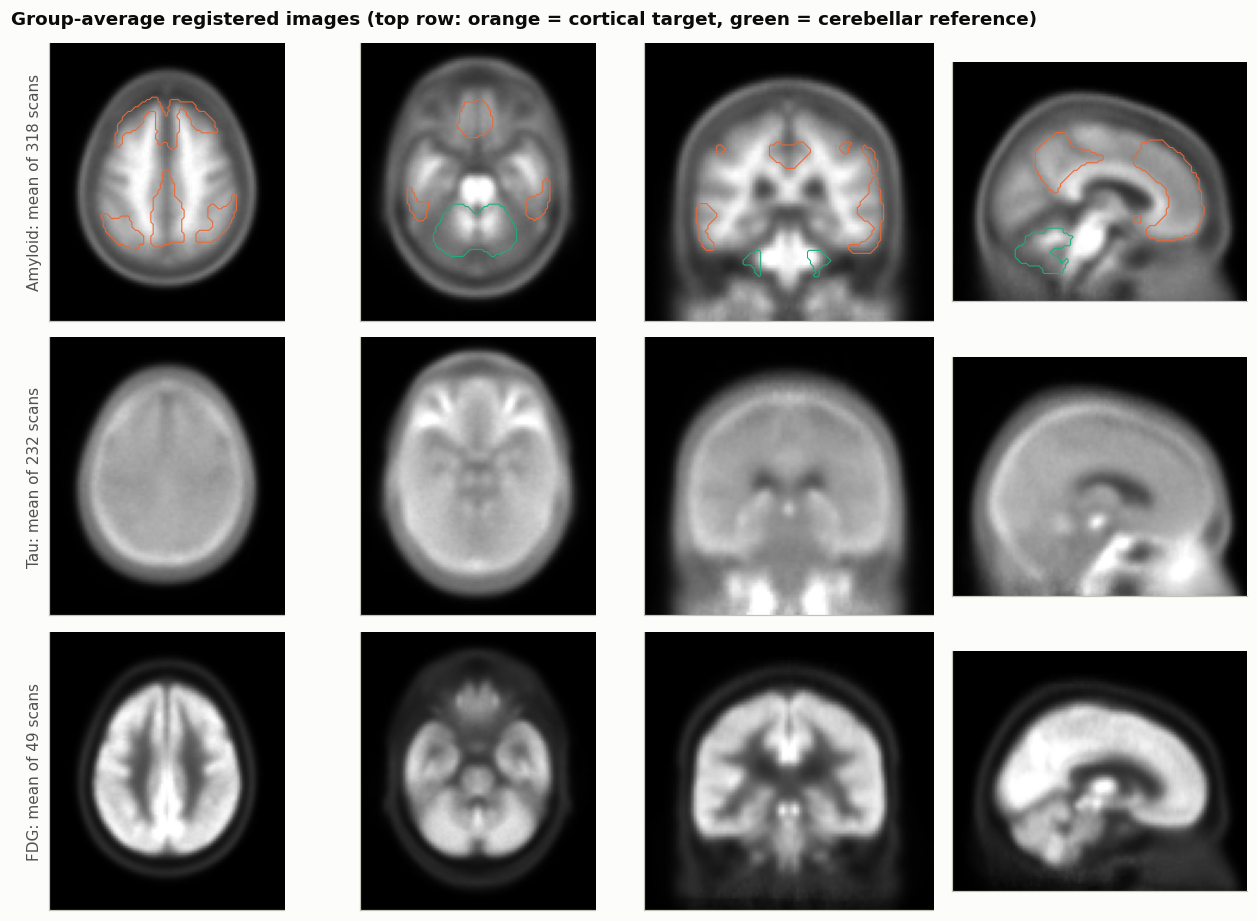

In [3]:
T = P / "pet_mni" / "templates"
voi = nu.REPO / "data" / "external" / "centiloid" / "Centiloid_Std_VOI" / "nifti" / "2mm"
def mean_image(modality):
    ids = reg[(reg["pass"] == 2) & reg.ok & (reg.modality == modality)].image_id
    total = None
    for i in ids:
        a = sitk.GetArrayFromImage(sitk.ReadImage(str(P / "pet_mni" / modality / f"{i}.nii.gz")))
        a = a / max(np.percentile(a, 99), 1e-6)
        total = a if total is None else total + a
    return total / len(ids), len(ids)
like = sitk.ReadImage(str(T / "mni152_t1_2mm.nii.gz"))
masks = {n: sitk.GetArrayFromImage(sitk.Resample(sitk.ReadImage(str(voi / f), sitk.sitkFloat32), like, sitk.Transform(), sitk.sitkNearestNeighbor, 0.0)) > 0
         for n, f in [("cortex", "voi_ctx_2mm.nii"), ("cerebellum", "voi_WhlCbl_2mm.nii")]}
fig, axes = plt.subplots(3, 4, figsize=(11.5, 8.5))
for row, modality in enumerate(["Amyloid", "Tau", "FDG"]):
    m, n = mean_image(modality)
    z, y, x = [s // 2 for s in m.shape]
    for j, sl in enumerate([np.s_[z + 8], np.s_[z - 22], np.s_[:, y - 8], np.s_[:, :, x + 3]]):
        axes[row, j].imshow(m[sl], cmap="gray", origin="lower", vmax=np.percentile(m, 99.7))
        if modality == "Amyloid":
            axes[row, j].contour(masks["cortex"][sl], colors=nu.ORANGE, linewidths=0.7); axes[row, j].contour(masks["cerebellum"][sl], colors=nu.AQUA, linewidths=0.7)
        axes[row, j].set_xticks([]); axes[row, j].set_yticks([]); axes[row, j].grid(False)
    axes[row, 0].set_ylabel(f"{modality}: mean of {n} scans")
fig.suptitle("Group-average registered images (top row: orange = cortical target, green = cerebellar reference)", x=0.01, ha="left", fontweight="bold")
fig.tight_layout(); nu.savefig(fig, "11_group_average_images"); plt.show()

The amyloid and FDG averages are sharp: white matter, ventricles, cortex and cerebellum are all recognisable, and the standard masks sit on the cortex and the cerebellum. The tau average shows the head and brain outline in the right place but little internal detail. That is expected: most of these participants are cognitively normal, so tau tracer uptake in the brain is low and even, and there is little contrast to see. It also means the tau registration is less well confirmed by eye than the amyloid one.

This is the visual check. The numeric check follows.

## 2. Does our SUVR agree with NACC's?

For each of the 318 amyloid scans, two SUVR values now exist for the same scan:

* **ours**, from the PET-only pipeline above;
* **NACC's** (`GAAINSUMMARYSUVR`), from the PET core's pipeline, which uses each person's MRI.

The two were computed independently. If they agree, both the conversion and the registration are doing the right thing.

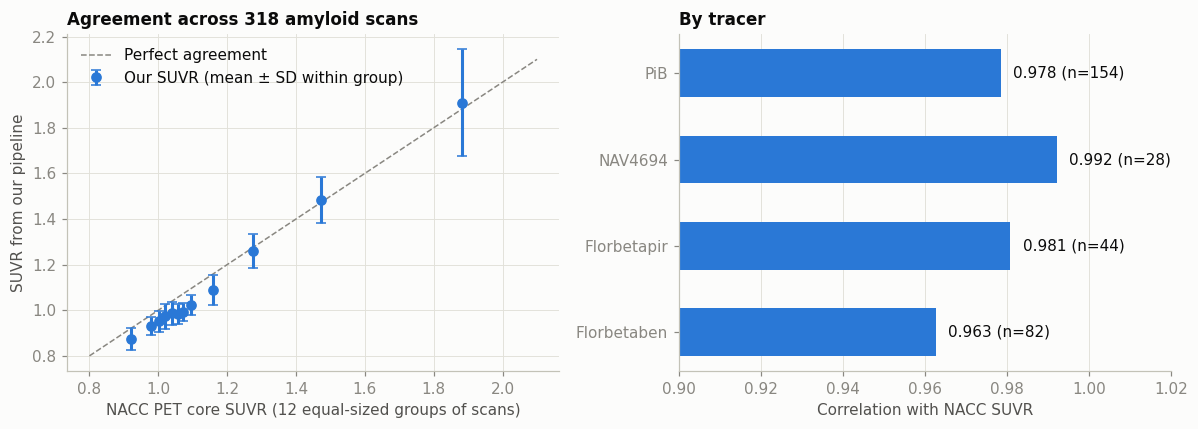

,All amyloid scans
Scans,318
Pearson correlation,0.977
Spearman correlation,0.885
Slope (ours on NACC's),1.1
Mean difference (ours minus NACC's),-0.043
95% limits of agreement,-0.18 to 0.09
AUROC for NACC's amyloid status,0.982


In [4]:
a, b = suv["all"], suv["binned"]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot([0.8, 2.1], [0.8, 2.1], color=nu.MUTED, ls="--", lw=1, label="Perfect agreement")
axes[0].errorbar(b["nacc"], b["image"], yerr=b["image_sd"], fmt="o", color=nu.BLUE, capsize=3, label="Our SUVR (mean ± SD within group)")
axes[0].set_xlabel("NACC PET core SUVR (12 equal-sized groups of scans)"); axes[0].set_ylabel("SUVR from our pipeline"); axes[0].legend(loc="upper left")
axes[0].set_title(f"Agreement across {a['n']} amyloid scans")
tr = pd.DataFrame(suv["by_tracer"]).T.drop(index="unknown", errors="ignore")
axes[1].barh(tr.index, tr.pearson_r.astype(float), color=nu.BLUE, height=0.55)
for y, (v, n) in enumerate(zip(tr.pearson_r, tr.n)): axes[1].text(float(v) + 0.003, y, f"{float(v):.3f} (n={int(n)})", va="center")
axes[1].set_xlim(0.9, 1.02); axes[1].set_xlabel("Correlation with NACC SUVR"); axes[1].set_title("By tracer"); axes[1].grid(axis="y", visible=False)
fig.tight_layout(); nu.savefig(fig, "11_suvr_agreement"); plt.show()
pd.DataFrame({"All amyloid scans": {"Scans": a["n"], "Pearson correlation": round(a["pearson_r"], 3), "Spearman correlation": round(a["spearman_r"], 3),
                                    "Slope (ours on NACC's)": round(a["slope"], 2), "Mean difference (ours minus NACC's)": round(a["mean_difference"], 3),
                                    "95% limits of agreement": f"{a['limits_of_agreement'][0]:.2f} to {a['limits_of_agreement'][1]:.2f}",
                                    "AUROC for NACC's amyloid status": round(a["auroc_for_amyloid_status"], 3)}})

In [5]:
pd.DataFrame(suv["by_scanner_maker"]).T[["n", "pearson_r", "mean_difference", "auroc_for_amyloid_status"]].astype(float).round(3).rename(
    columns={"n": "Scans", "pearson_r": "Pearson correlation", "mean_difference": "Mean difference", "auroc_for_amyloid_status": "AUROC for amyloid status"})

,Scans,Pearson correlation,Mean difference,AUROC for amyloid status
Ge Medical Systems,112.0,0.983,-0.046,0.995
Philips,29.0,0.966,-0.058,0.992
Siemens,177.0,0.975,-0.039,0.970


**The pipeline is validated.**

* Correlation with NACC's values is **0.98** across all 318 scans, and 0.96 to 0.99 for each tracer and each scanner maker.
* Our single SUVR number separates NACC's amyloid-positive from amyloid-negative scans with an **AUROC of 0.98**.
* There is a small systematic offset: our values are about 0.04 lower on average, and the slope is 1.1, meaning ours run a little lower at the low end and a little higher at the high end. This is expected. The two pipelines use different region definitions (standard-space masks here, each person's own MRI-based regions at NACC), and without an MRI our cortical region includes some white matter and CSF.

So the numbers are not interchangeable with NACC's without a calibration, but they measure the same thing. That is the purpose of this step: to show, with independent evidence, that raw scanner files were turned into correct quantitative images.

The lower Spearman value (0.89) reflects the many amyloid-negative scans bunched around SUVR 1.0, where small differences reorder scans without meaning.

Tau and FDG images were converted and registered in the same way. A matching check for tau needs a standard meta-temporal region mask, which was not available, so tau quantification from images is left as future work.

## 3. An image model: amyloid positive or negative?

**Why this target.** Nearly every amyloid image has a label from the PET core (positive or negative), so there are enough examples of both classes. It lets the project demonstrate a 3D convolutional network and Grad-CAM on real data, honestly.

**Three models, 5-fold cross-validation** (each scan is scored by a model that never saw it; folds are balanced by status and tracer):

| Model | Input | Fitted parameters |
|---|---|---|
| Cortical SUVR | One number per scan (section 2) | None: the number is used directly |
| Regional logistic model | Mean uptake in a coarse grid of blocks | About a thousand, strongly regularised |
| 3D CNN | The whole volume, 80 x 96 x 80 voxels, each divided by its cerebellar mean | See below |

The CNN has four convolution stages and global average pooling, trained for 40 epochs with flips, small shifts and intensity changes as augmentation.

292 labelled scans, 84 amyloid positive. CNN weights: 494,917. Tracers: {'PiB': 128, 'Florbetaben': 82, 'Florbetapir': 44, 'NAV4694': 28, 'unknown': 10}


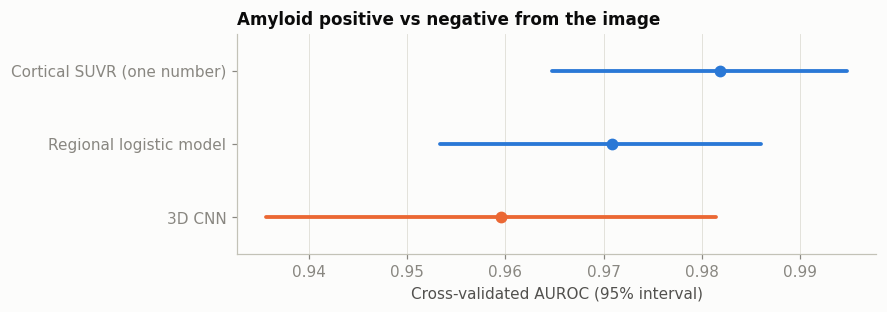

CNN AUROC by tracer: {'Florbetapir': 0.969, 'NAV4694': 0.971, 'PiB': 0.972, 'Florbetaben': 0.953}


,AUROC (95% interval),AUPRC,Difference from cortical SUVR
Cortical SUVR (one number),0.982 (0.965-0.995),0.972,reference
Regional logistic model,0.971 (0.953-0.986),0.947,-0.011 (-0.026 to +0.004)
3D CNN,0.960 (0.936-0.981),0.933,-0.022 (-0.043 to -0.003)


In [6]:
cnn = json.loads((nu.REPORTS / "phase5_pet_cnn_results.json").read_text())
print(f"{cnn['n']} labelled scans, {cnn['positive']} amyloid positive. CNN weights: {cnn['cnn_parameters']:,}. Tracers: {cnn['tracers']}")
rows = {}
for name, m in cnn["models"].items():
    rows[name] = {"AUROC (95% interval)": f"{m['auroc']:.3f} ({m['auroc_ci'][0]:.3f}-{m['auroc_ci'][1]:.3f})", "AUPRC": round(m["auprc"], 3),
                  "Difference from cortical SUVR": "reference" if "delta_auroc" not in m else f"{m['delta_auroc']:+.3f} ({m['delta_auroc_ci'][0]:+.3f} to {m['delta_auroc_ci'][1]:+.3f})"}
fig, ax = plt.subplots(figsize=(7.5, 2.6))
for i, (name, m) in enumerate(list(cnn["models"].items())[::-1]):
    c = nu.ORANGE if "CNN" in name else nu.BLUE
    ax.plot(m["auroc_ci"], [i, i], color=c, lw=2.5, solid_capstyle="round"); ax.scatter([m["auroc"]], [i], color=c, s=45, zorder=3)
ax.set_yticks(range(len(cnn["models"])), list(cnn["models"])[::-1]); ax.set_xlabel("Cross-validated AUROC (95% interval)"); ax.grid(axis="y", visible=False); ax.set_ylim(-0.5, 2.5)
ax.set_title("Amyloid positive vs negative from the image"); nu.savefig(fig, "11_image_models"); plt.show()
print("CNN AUROC by tracer:", {k: round(v, 3) for k, v in cnn["cnn_auroc_by_tracer"].items()})
pd.DataFrame(rows).T

**The single SUVR number wins.**

* Cortical SUVR alone: AUROC 0.982.
* Regional logistic model: 0.971 (difference from SUVR not significant).
* 3D CNN: 0.960, **significantly lower** than the SUVR number (difference -0.022, interval -0.043 to -0.003).

The CNN works: 0.96 from raw volumes with about 230 training scans per fold is a competent result, and it holds across all four tracers (0.95 to 0.97). But it does not beat one hand-defined measurement.

**Why this is the expected outcome, not a failure.**

* The label *is* a thresholded SUVR. The PET core decided "positive" from a cortical uptake ratio, so a cortical uptake ratio is very nearly the definition of the target. The CNN has to rediscover that ratio from half a million weights and under 300 examples.
* Deep learning pays off when there are many examples and the useful pattern is not known in advance. Here there are few examples and the pattern has been known for twenty years.

**What to conclude.** For amyloid status the standard quantitative measure should be used. The CNN is reported as a tested alternative that was not better. This is the same lesson as the tabular models in notebook 06, reached independently on images.

### Grad-CAM: where does the network look?

Grad-CAM asks which parts of the image most increased the network's "amyloid positive" output. The maps for correctly detected positive scans are averaged, so the picture shows the network's typical behaviour and not any one person.

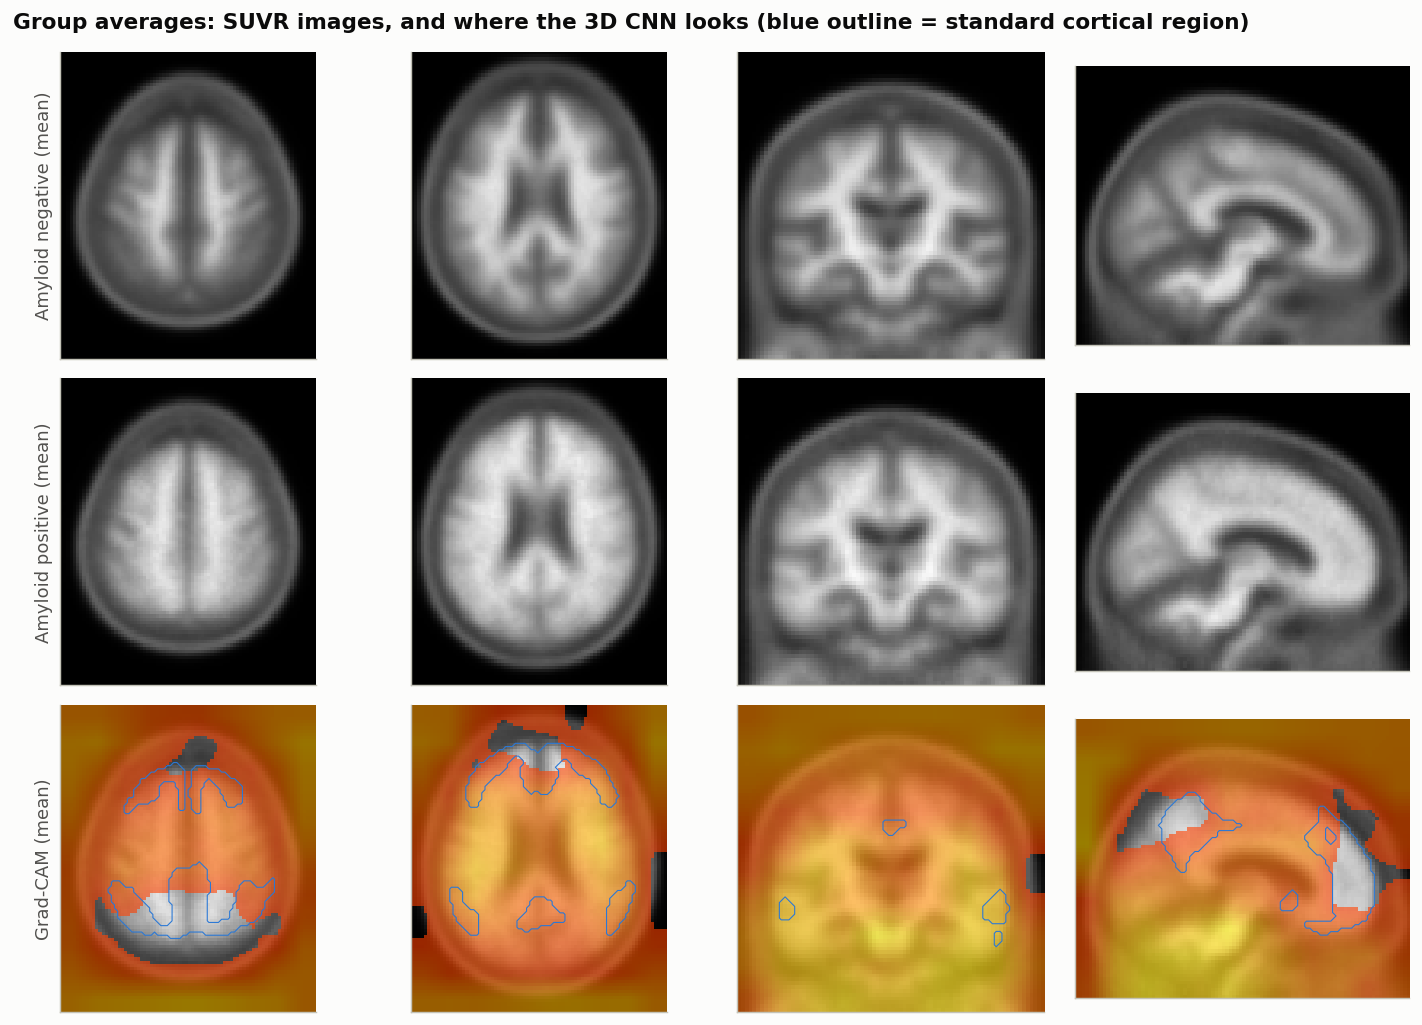

Averaged over 72 correctly detected amyloid-positive scans.
Share of the strongest 5% of the map inside the standard cortical region: 2% (that region is 4% of the volume, so 4% is what chance would give)


In [7]:
from IPython.display import Image, display
display(Image(filename=str(nu.FIGURES / "11_gradcam_mean.png")))
g = cnn["grad_cam"]
print(f"Averaged over {g['scans_averaged']} correctly detected amyloid-positive scans.")
print(f"Share of the strongest 5% of the map inside the standard cortical region: {g['share_of_top5pct_inside_cortical_region'] * 100:.0f}% "
      f"(that region is {g['share_expected_by_chance'] * 100:.0f}% of the volume, so {g['share_expected_by_chance'] * 100:.0f}% is what chance would give)")

**The Grad-CAM map is diffuse and does not single out the cortex.**

* 96% of the volume has a Grad-CAM value above a quarter of the maximum. The map covers almost everything.
* The strongest 5% of the map lies mostly *outside* the standard cortical region (about 2% inside, when 4% would be chance). The map is brightest low and central (cerebellum, brainstem, deep white matter) and weakest over the frontal and posterior cortex, which is where amyloid actually accumulates.

**How to read this honestly.**

* Amyloid status is a *ratio*: cortex relative to a reference. A network can pick it up by attending to the reference and white-matter regions as much as to the cortex. So the map is not necessarily wrong, but it does not give the simple "it looks at the cortex" picture one would hope to show a clinician.
* Grad-CAM here is coarse by construction. The last feature map is 10 x 12 x 10, so each cell covers roughly 2 cm of brain, and the network ends in a global average, which spreads responsibility over the whole volume.
* Averaging over 72 scans smooths it further.

**So Grad-CAM did not provide a convincing, anatomically specific explanation in this project.** That should be reported as it is. The SUVR measurement is both more accurate and far easier to explain: "uptake in these cortical regions relative to the cerebellum". For this task the interpretable method and the accurate method are the same one.

## 4. Summary

| Step | Result |
|---|---|
| Raw dynamic DICOM to static 3D images | 599 of 599 scans converted |
| Registration to a common space (two passes, PET only) | 599 of 599; amyloid and FDG group averages are sharp, tau less distinct |
| Amyloid SUVR from our images against NACC's values | Correlation 0.98 over 318 scans; AUROC 0.98 for amyloid status |
| Amyloid status from the image: SUVR number / regional model / 3D CNN | AUROC 0.982 / 0.971 / 0.960 |
| Grad-CAM | Diffuse; did not localise the cortical target region |

**What can be claimed**

* A PET-only preprocessing pipeline was built from raw scanner files and **independently validated** against the PET core's values.
* A 3D CNN can identify amyloid status from the processed images (AUROC 0.96), but a single standard measurement does better (0.98).

**What cannot be claimed**

* That images predict cognitive decline. This was not tested, because the data cannot test it (5 conversions).
* That Grad-CAM showed the network attending to amyloid-relevant cortex. It did not.
* That our SUVR values are interchangeable with NACC's. They correlate at 0.98 but sit on a slightly different scale.

**Limits**

* No MRI, so regions come from standard-space masks, not each person's anatomy.
* Frames were averaged without frame-to-frame motion correction.
* Tau and FDG images were converted and registered but not quantified.
* Three scans have unusable injection-time headers; all of their frames were averaged.
* The CNN was trained once per fold with one architecture and light tuning.

### How the images connect to the rest of the system

The interface accepts PET **measures** (Centiloids, amyloid status, tau SUVR), not image files. That is deliberate: this notebook shows that a quantitative measure can be produced from a raw scan and that it carries the image's useful information for this purpose, and notebook 08 shows how such measures enter the risk estimate. Uploading a raw DICOM series and running this pipeline inside the interface is possible in principle, but each scan needs the visual checks described above before its numbers can be trusted, which is not something to hide behind a button.